In [1]:
import sys

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

import scanpy as sc
import scvi

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all" # to show output from all the lines in a cells
pd.set_option('display.max_column',None) # display all the columns in pandas
pd.options.display.max_rows = 100

from datetime import date
today = str(date.today())

import matplotlib
from matplotlib import rcParams
rcParams['pdf.fonttype'] = 42
sc.settings.set_figure_params(dpi = 150, color_map = 'RdPu', dpi_save = 600, vector_friendly = True, format = 'pdf')

#%cd /...
import scrublet as scr
from doubletdetection import *

#folder = '/...

G:\Miniconda3\envs\omicverse\lib\site-packages\anndata\utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
G:\Miniconda3\envs\omicverse\lib\site-packages\anndata\utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
G:\Miniconda3\envs\omicverse\lib\site-packages\anndata\utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
G:\Miniconda3\envs\omicverse\lib\site-packages\anndata\utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
G:\Miniconda3\envs\omicverse\lib\site-packages\anndata\utils.py:429: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  war

ModuleNotFoundError: No module named 'doubletdetection'

In [2]:
def Barplot(which_var, adata, var='clusters', height=3, color = False):
    plotdata = pd.crosstab(adata.obs[var], adata.obs[which_var], normalize='index') * 100
    if 'category' in plotdata.index.dtype.name:
        plotdata.index.reorder_categories(adata.obs[var].cat.categories[::-1])

    if not color:
        ax1 = plotdata.plot.barh(stacked = True, edgecolor = 'none', zorder = 3, figsize = (6,height), fontsize = 14, grid = False)
    else:
        ax1 = plotdata.plot.barh(stacked = True, edgecolor = 'none', zorder = 3, figsize = (6,height), fontsize = 14, grid = False, color = color)
    ax1.set_title(which_var+' %')
    ax1.set_ylabel(var)
    horiz_offset = 1
    vert_offset = 1.
    ax1 = ax1.legend(bbox_to_anchor = (horiz_offset, vert_offset))
#     ax1.figure.savefig(str(sc.settings.figdir)+'/barplot_'+var+'_proportions_'+which_var+'.pdf', bbox_inches='tight',
#                        dpi=300, orientation='landscape', format= 'pdf', optimize=True)

In [3]:
palette = ["#E31A1C", "#1F78B4", "#A6CEE3",  "#B2DF8A", "#33A02C", "#FB9A99",  "#FDBF6F", "#FF7F00", "#CAB2D6", "#6A3D9A", "#FFFF99", "#B15928", "#66C2A5",
               "#FC8D62", "#8DA0CB", "#B3B3B3", "#A6D854", "#FFD92F", "#E5C494", "#E78AC3"]

# set up scVI Environment

In [4]:
import scvi
import scanpy as sc
import pandas as pd 
import numpy as np
sc.set_figure_params(figsize=(4, 4))

In [5]:
cd F:\PROJECTS\PROJECT_HUMAN_FETAL_COCHLEAE\WORKPLACE\R\sc_pipeline\

F:\PROJECTS\PROJECT_HUMAN_FETAL_COCHLEAE\WORKPLACE\R\sc_pipeline


G:\Miniconda3\envs\omicverse\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [6]:
data_dir = '/PROJECTS/PROJECT_HUMAN_FETAL_COCHLEAE/WORKPLACE/R/sc_pipeline/'
meta = pd.read_csv(data_dir+'metadata.csv',index_col=0)
meta

,sample_id,donor,gw,gender,10xKit,sequencing,dataset
sample,,,,,,,
9.5gw,gw9,not_provided_1,9,female,SC3,snRNA-seq,public
11.2gw,gw11,not_provided_2,11,male,SC3,snRNA-seq,public
14+3gw,gw14,F20240701,14,male,SC3,snRNA-seq,in-house
15gw,gw15,not_provided_3,15,female,SC3,scRNA-seq,public
16+4gw,gw16,F20241018,16,male,SC3,snRNA-seq,in-house
17+2gw,gw17_1,F20220807,17,male,SC3,snRNA-seq,in-house
17+3gw,gw17_2,F20240928,17,female,SC3,snRNA-seq,in-house
17gw,gw17_3,not_provided_4,17,male,SC3,scRNA-seq,public
18+3gw,gw18,F20220806,18,male,SC3,snRNA-seq,in-house


In [7]:
adata = sc.read(data_dir + 'all_rawcounts.h5ad')

In [8]:
adata

AnnData object with n_obs × n_vars = 101419 × 13994
    obs: 'batch', 'CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'louvain', 'cell_type', 'n_genes', 'sample', 'sample_id', 'donor', 'gw', 'gender', '10xKit', 'sequencing', 'dataset', 'percent_mito', 'n_counts', 'nCount_RNA', 'nFeature_RNA', 'leiden_R', 'low_ncounts', 'high_mito', 'low_ncounts_high_mito', 'S_score', 'G2M_score', 'phase', 'scrublet_score', 'scrublet_cluster_score', 'zscore', 'bh_pval', 'bonf_pval', 'is_doublet'
    var: 'Gene', 'mt', 'gene_ids-0', 'feature_types-0', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'highly_variable-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'n_cells-0', 'gene_ids-1', 'feature_types-1', 'n_cells_by_counts-1', 'mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'highly_variable-1', 'means-1', 'dispersions-1', 'dispersions_norm-1', 'n_cells-1', 'gene_ids-10', 'feature_types-10', 'n_cells_b

In [9]:
adata.layers["counts"] = adata.X.copy() # preserve counts

In [11]:
adata.obs['sample'].value_counts()

sample
gw25      13936
gw14      12051
gw18       9546
gw16       8701
gw22_2     7844
gw26       7589
gw17_2     7087
gw17_1     6768
gw22_1     5647
gw17_3     4538
gw9        4284
gw11       4050
gw20       3689
gw23       3543
gw15       2146
Name: count, dtype: int64

In [16]:
def run_scvi(adata, batch_hv = "sample", batch_scvi = "gw", \
             cat_cov_scvi = ["sample",  "sequencing", "gender","dataset"], cont_cov_scvi = ["percent_mito"], \
             include_genes = [], exclude_cc_genes=True, vae_name = "", **kwargs):
    #adata_scvi = sc.AnnData(X = adata.layers['counts'].copy(), obs = adata.obs.copy(), var = adata.var.copy())
    adata_scvi = adata.copy()
    adata_scvi.layers["counts"] = adata_scvi.X.copy()
    sc.pp.normalize_total(adata_scvi, target_sum=1e4)
    sc.pp.log1p(adata_scvi)
     # keep full dimension safe
    sc.pp.highly_variable_genes(adata_scvi, flavor="seurat_v3", n_top_genes=10000, layer="counts",\
                                batch_key=batch_hv)
    selected_genes = list(set(adata_scvi.var.loc[adata_scvi.var['highly_variable']].index.tolist()+ include_genes))
    print(len(selected_genes))

    adata_scvi = adata_scvi[:, selected_genes].copy()
    scvi.model.SCVI.setup_anndata(adata_scvi, layer="counts", batch_key=batch_scvi, \
                             categorical_covariate_keys=cat_cov_scvi, \
                             continuous_covariate_keys=cont_cov_scvi)
    scvi_kwargs = {k: v for k,v in kwargs.items() if k in scvi.model.SCVI.__init__.__code__.co_varnames}
    vae = scvi.model.SCVI(adata_scvi, **scvi_kwargs)
    train_kwargs = {k: v for k,v in kwargs.items() if k in vae.train.__code__.co_varnames}
    vae.train(**train_kwargs)
    adata_scvi.obsm["X_scVI"] = vae.get_latent_representation()
    
    
    return(adata_scvi)

In [18]:
adata_scvi = run_scvi(adata, batch_hv = "sample", batch_scvi = "gw", \
             cat_cov_scvi = ["sample",  "sequencing", "gender","dataset"], cont_cov_scvi = ["percent_mito"], \
             #include_genes = all_mrkrs,  
                      #vae_name = "cochlea_snuclei", 
   n_hidden=512, n_layers=2, n_latent=50, gene_likelihood='nb', dispersion='gene-batch',use_observed_lib_size=False,
                           train_size=0.99, max_epochs=1000, batch_size=1024, early_stopping = True)

G:\Miniconda3\envs\omicverse\lib\site-packages\scanpy\preprocessing\_highly_variable_genes.py:75: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(


10000


G:\Miniconda3\envs\omicverse\lib\site-packages\scvi\data\fields\_base_field.py:63: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
G:\Miniconda3\envs\omicverse\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=47` in the `DataLoader` to improve performance.
G:\Miniconda3\envs\omicverse\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=47` in the `DataLoader` to improve performance.


Training:   0%|          | 0/1000 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 45 records. Best score: 3399.124. Signaling Trainer to stop.


In [22]:
adata_scvi

AnnData object with n_obs × n_vars = 101419 × 10000
    obs: 'batch', 'CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'louvain', 'cell_type', 'n_genes', 'sample', 'sample_id', 'donor', 'gw', 'gender', '10xKit', 'sequencing', 'dataset', 'percent_mito', 'n_counts', 'nCount_RNA', 'nFeature_RNA', 'leiden_R', 'low_ncounts', 'high_mito', 'low_ncounts_high_mito', 'S_score', 'G2M_score', 'phase', 'scrublet_score', 'scrublet_cluster_score', 'zscore', 'bh_pval', 'bonf_pval', 'is_doublet', '_scvi_batch', '_scvi_labels'
    var: 'Gene', 'mt', 'gene_ids-0', 'feature_types-0', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'highly_variable-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'n_cells-0', 'gene_ids-1', 'feature_types-1', 'n_cells_by_counts-1', 'mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'highly_variable-1', 'means-1', 'dispersions-1', 'dispersions_norm-1', 'n_cells-1', 'gene_ids-10',

In [27]:
sc.pp.neighbors(adata_scvi, use_rep="X_scVI")
sc.tl.leiden(adata_scvi)
sc.tl.umap(adata_scvi)    

C:\Users\Dell\AppData\Local\Temp\ipykernel_31808\1627013862.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_scvi)


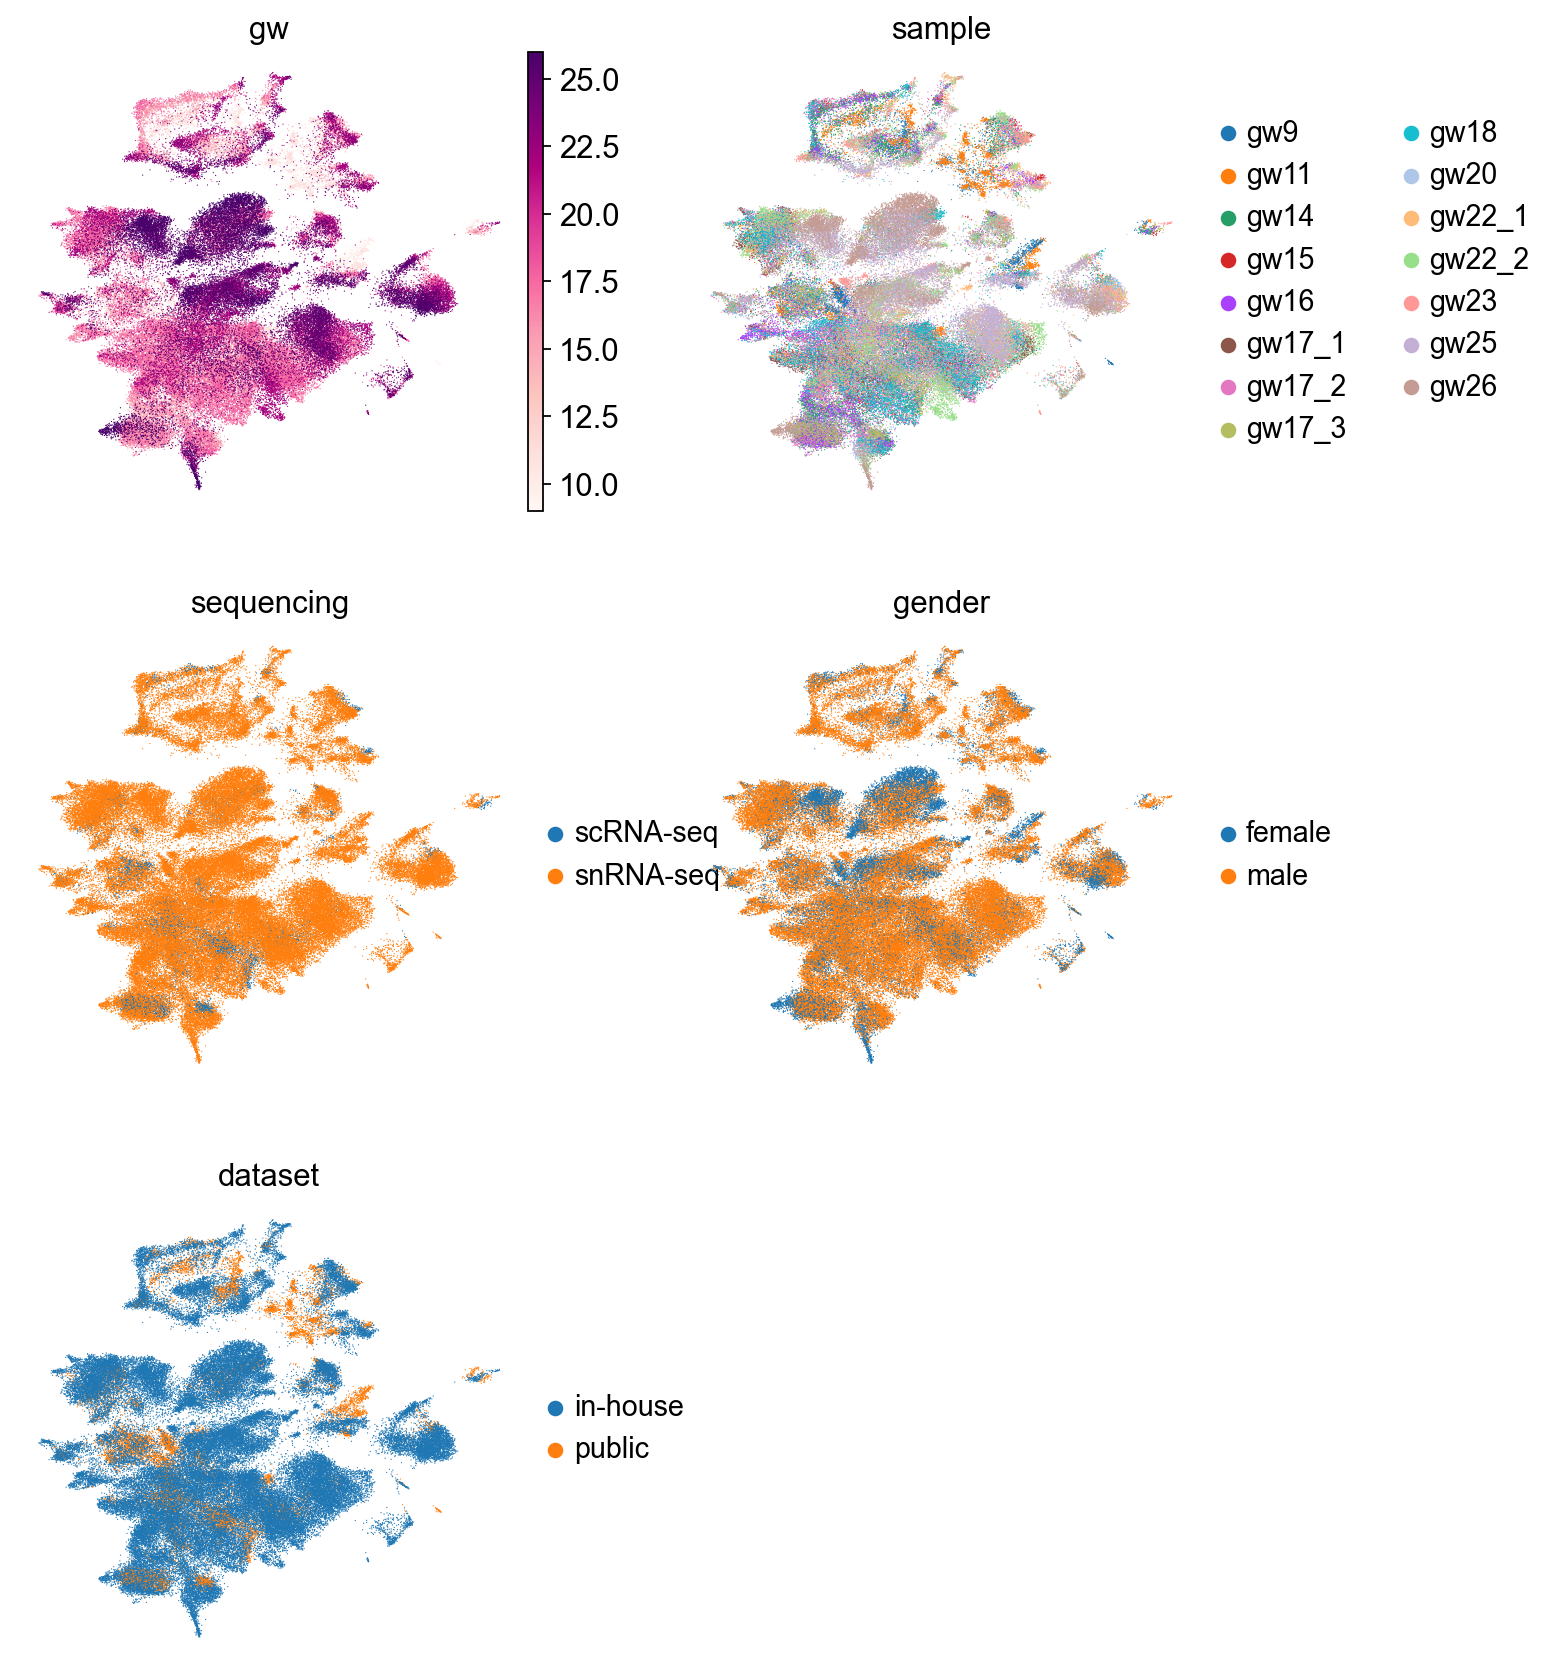

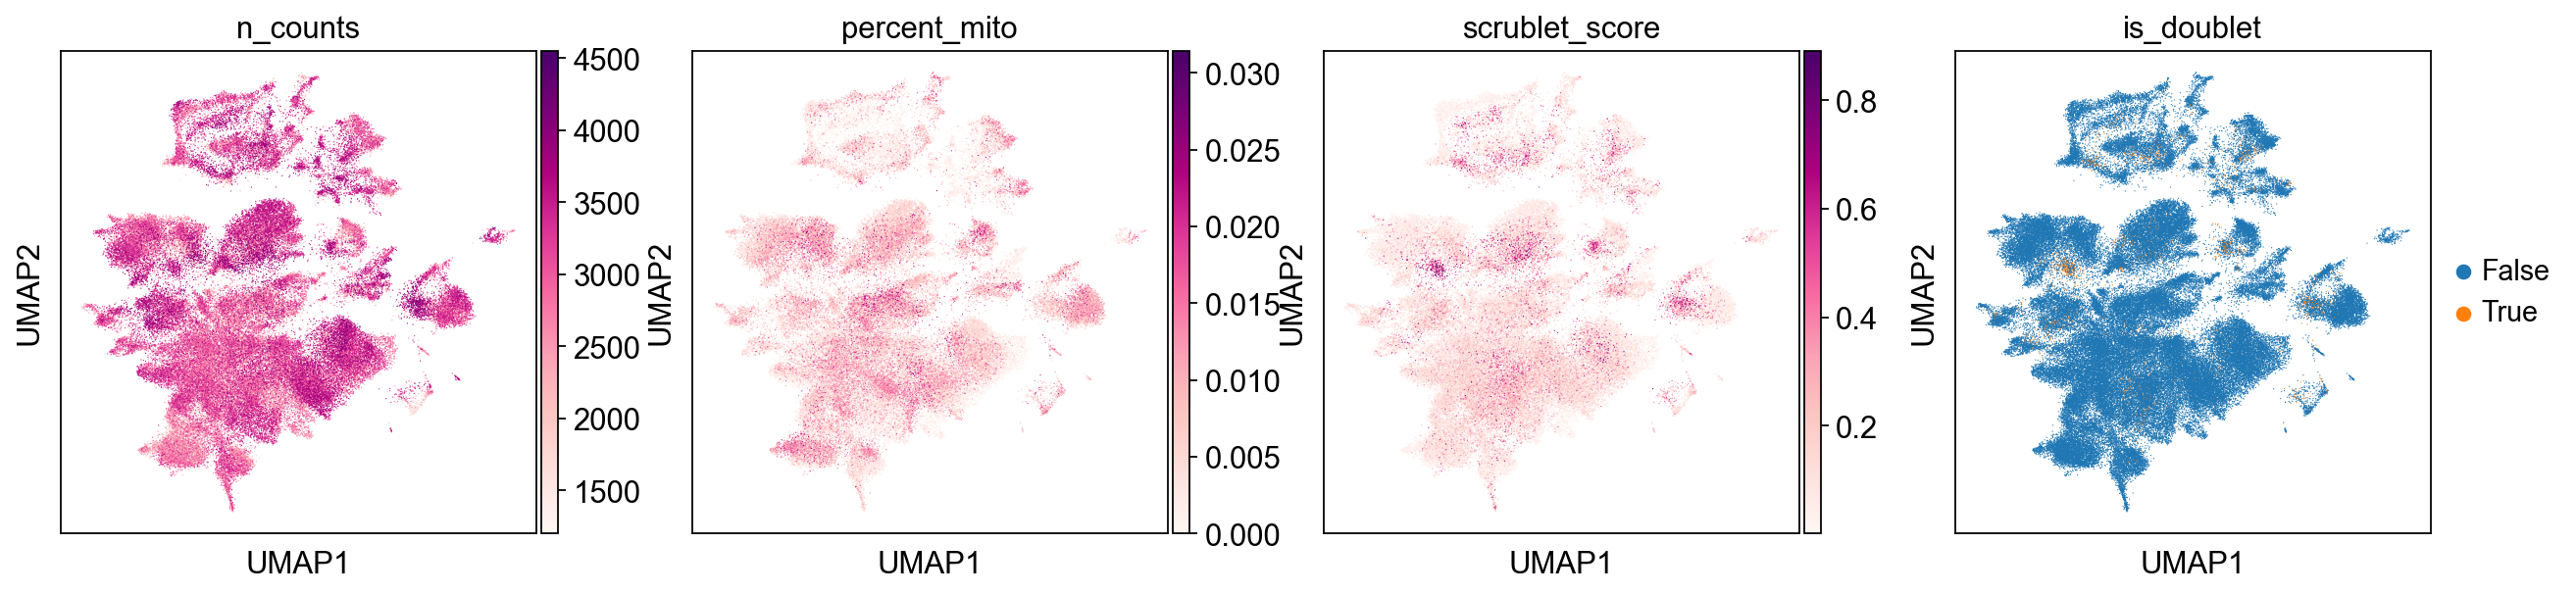

In [29]:
adata_raw_scvi = adata.copy()
adata_raw_scvi.obsm['X_scVI'] = adata_scvi.obsm['X_scVI'].copy()
adata_raw_scvi.obsm['X_umap'] = adata_scvi.obsm['X_umap'].copy()
adata_raw_scvi.obsp = adata_scvi.obsp.copy()
adata_raw_scvi.uns = adata_scvi.uns.copy()
adata_raw_scvi.obs['leiden'] = adata_scvi.obs['leiden'].copy()
    
sc.pl.umap(
        adata_raw_scvi,
        color=[ "gw",  "sample",  "sequencing", "gender","dataset"],
        frameon=False,
        ncols=2,
    )
sc.pl.umap(
        adata_raw_scvi,
        color=['n_counts',  'percent_mito',  \
               'scrublet_score', 'is_doublet'])

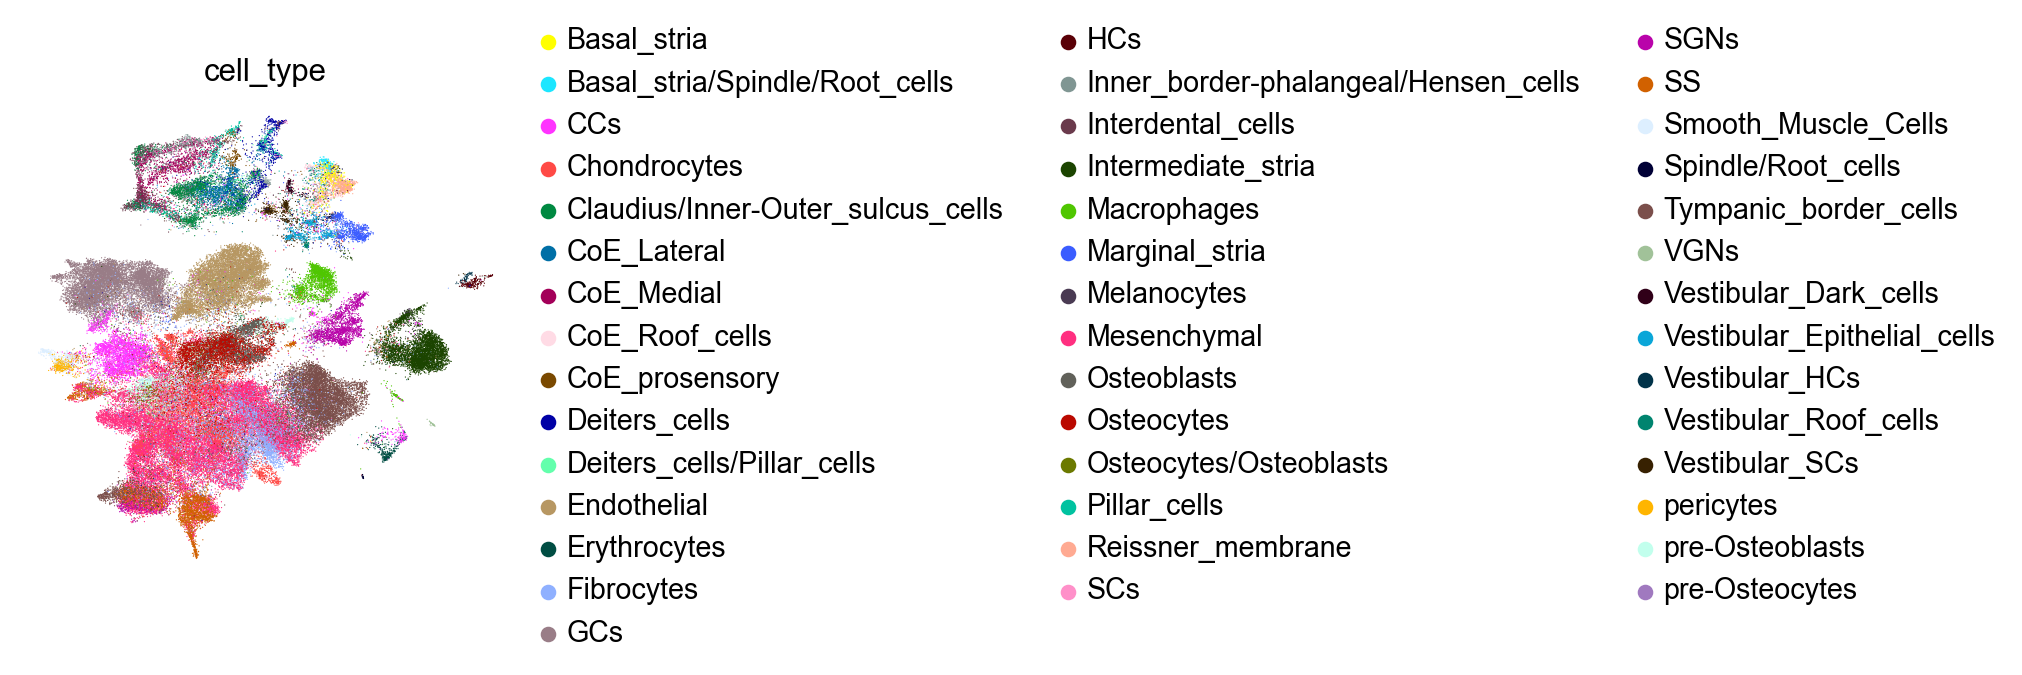

In [30]:
sc.pl.umap(
        adata_raw_scvi,
        color=[ "cell_type", ],
        frameon=False,
        ncols=2,
    )

In [31]:
sc.settings.figdir = './figures/processing/'

In [32]:
#Save latent space
pd.DataFrame(adata_raw_scvi.obsm["X_scVI"]).to_csv(data_dir + 'all_XscVI_latent_space.csv')

In [33]:
adata_raw_scvi.write('scvi_integrated_raw.h5ad')